In [1]:
# 日本語対応のモジュールをインストールする（その１）
!pip install japanize-matplotlib

# 日本語対応のモジュールをインストールする（その２）
!apt-get install -y fonts-ipafont-gothic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=a30082b149193a343661c668d1c92ef2d921d1e37d759248c6946873213f3136
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://ar

In [5]:
# 各ライブラリーをインポートする
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import warnings
warnings.filterwarnings("ignore")

# アソシエーション分析（mlxtend）
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 異常検知（scikit-learn）
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# 乱数シードを固定
RANDOM_STATE = 42

URL = "https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/2023-06-29/data/listings.csv.gz"
df = pd.read_csv(URL, compression="gzip", low_memory=False)
print(f"読み込み完了：{df.shape[0]:,} 行 × {df.shape[1]} 列")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

読み込み完了：11,177 行 × 75 列


In [6]:
# Airbnbの amenities 列は、各物件が備える設備のリストが
# 文字列として入っています。
# 例： '["Wifi", "Kitchen", "Washer", ...]'
# これを「1物件＝1かご、各設備＝アイテム」と見立てます。

# amenities列の中身
for s in df["amenities"].head(3):
    print(" -", s[:80], "...")

import ast

def parse_amenities(x):
    """文字列のリストを Python のリストに変換する。失敗したら空リスト。"""
    try:
        items = ast.literal_eval(x)
        # 表記ゆれを抑えるため、前後の空白を除去
        return [str(i).strip() for i in items]
    except Exception:
        return []

baskets = df["amenities"].apply(parse_amenities).tolist()

# 空のかごは除外
baskets = [b for b in baskets if len(b) > 0]
print(f"\n有効なかご（物件）の数：{len(baskets):,}")
print(f"1かごあたりの平均アイテム数：{np.mean([len(b) for b in baskets]):.1f}")
# アメニティは種類が非常に多く、珍しすぎる設備まで含めると
# 規則が見つけにくくなります。出現頻度の高い上位の設備に絞ります。
from collections import Counter

# 全アイテムの出現回数を数える
counter = Counter(item for basket in baskets for item in basket)
print(f"ユニークなアイテム（設備）の種類：{len(counter):,}")

# 出現頻度トップ20を確認
print("\n■ よく登場する設備トップ20：")
for item, cnt in counter.most_common(20):
    print(f" {cnt:6,d} 件 {item}")

# 上位30種類だけを残す（演習を見やすくするため）
TOP_N = 30
top_items = set(item for item, _ in counter.most_common(TOP_N))

# 各かごを「上位アイテムだけ」に絞り込む
baskets_top = [[i for i in basket if i in top_items] for basket in baskets]
baskets_top = [b for b in baskets_top if len(b) > 0]
print(f"\n上位{TOP_N}種類に絞った後のかご数：{len(baskets_top):,}")

 - ["Dryer", "Free washer \u2013 In unit", "Smoke alarm", "Shampoo", "Carbon monoxi ...
 - ["Smoke alarm", "Shampoo", "Air conditioning", "Cleaning products", "Piano", "Fi ...
 - ["Private patio or balcony", "Room-darkening shades", "Laundromat nearby", "Baby ...

有効なかご（物件）の数：11,170
1かごあたりの平均アイテム数：28.9
ユニークなアイテム（設備）の種類：1,785

■ よく登場する設備トップ20：
 10,805 件 Hair dryer
 10,640 件 Smoke alarm
 10,567 件 Essentials
 10,266 件 Wifi
 10,101 件 Shampoo
  9,710 件 Hangers
  9,495 件 Fire extinguisher
  9,331 件 Air conditioning
  9,247 件 Kitchen
  9,205 件 Hot water
  8,929 件 Refrigerator
  8,597 件 Heating
  8,524 件 Microwave
  8,248 件 Dishes and silverware
  7,016 件 Washer
  6,986 件 Long term stays allowed
  6,959 件 Self check-in
  6,683 件 Bed linens
  6,514 件 TV
  6,347 件 Carbon monoxide alarm

上位30種類に絞った後のかご数：11,170


In [7]:
# mlxtend は「どのかごにどのアイテムが入っているか」を
# True/False の表（ワンホット形式）で受け取ります。
# TransactionEncoder がこの変換をしてくれます。
te = TransactionEncoder()
te_array = te.fit_transform(baskets_top)
df_basket = pd.DataFrame(te_array, columns=te.columns_)
print(f"変換後の表：{df_basket.shape[0]:,} 行（かご） × {df_basket.shape[1]} 列（アイテム）")
print("\n表の一部（先頭5かご・先頭6アイテム）：")
print(df_basket.iloc[:5, :6])

変換後の表：11,170 行（かご） × 30 列（アイテム）

表の一部（先頭5かご・先頭6アイテム）：
   Air conditioning  Bathtub  Bed linens  Body soap  Carbon monoxide alarm  \
0              True    False       False      False                   True   
1              True    False        True      False                  False   
2             False    False        True      False                   True   
3             False     True        True      False                   True   
4              True     True        True       True                   True   

   Conditioner  
0        False  
1        False  
2        False  
3        False  
4         True  


In [8]:
# min_support：このしきい値より頻繁に出る組み合わせだけを残す。
# 0.50 = 「全かごの50%以上に現れる組み合わせ」
# しきい値を下げるほどたくさんの組み合わせが見つかりますが、
# 計算が重くなり、珍しい組み合わせも混ざります。
MIN_SUPPORT = 0.40
freq_itemsets = apriori(df_basket, min_support=MIN_SUPPORT, use_colnames=True)
freq_itemsets = freq_itemsets.sort_values("support", ascending=False)
print(f"min_support={MIN_SUPPORT} で見つかった頻出アイテム集合：{len(freq_itemsets)} 個")
print("\n■ 支持度トップ10：")
for _, row in freq_itemsets.head(10).iterrows():
    items = ", ".join(list(row["itemsets"]))
    print(f" support={row['support']:.3f} {{{items}}}")

min_support=0.4 で見つかった頻出アイテム集合：28510 個

■ 支持度トップ10：
 support=0.967 {Hair dryer}
 support=0.953 {Smoke alarm}
 support=0.946 {Essentials}
 support=0.940 {Essentials, Hair dryer}
 support=0.927 {Smoke alarm, Hair dryer}
 support=0.919 {Wifi}
 support=0.907 {Smoke alarm, Essentials}
 support=0.904 {Shampoo}
 support=0.902 {Smoke alarm, Essentials, Hair dryer}
 support=0.899 {Shampoo, Hair dryer}


見つかった連関規則：3341894 件

■ リフトが高い規則トップ10（X → Y）：
------------------------------------------------------------------------------
 [Conditioner, Hair dryer] → [Shampoo, Body soap]
  support=0.400  confidence=0.849  lift=1.95
 [Shampoo, Body soap] → [Conditioner, Hair dryer]
  support=0.400  confidence=0.917  lift=1.95
 [Conditioner] → [Shampoo, Body soap]
  support=0.401  confidence=0.849  lift=1.95
 [Shampoo, Body soap] → [Conditioner]
  support=0.401  confidence=0.920  lift=1.95
 [Shampoo, Body soap, Hair dryer] → [Conditioner]
  support=0.400  confidence=0.920  lift=1.95
 [Conditioner] → [Shampoo, Body soap, Hair dryer]
  support=0.400  confidence=0.846  lift=1.95
 [Conditioner, Shampoo, Hair dryer] → [Body soap]
  support=0.400  confidence=0.855  lift=1.93
 [Body soap] → [Conditioner, Shampoo, Hair dryer]
  support=0.400  confidence=0.902  lift=1.93
 [Conditioner, Shampoo] → [Body soap]
  support=0.401  confidence=0.855  lift=1.93
 [Body soap] → [Conditioner, Shampoo]
  support=0.401  co

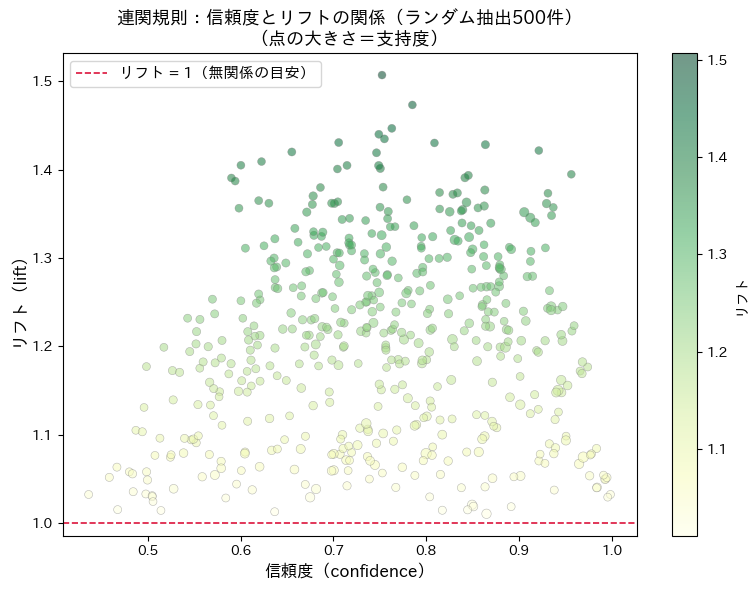

In [10]:
# association_rules が「X → Y」という規則を作り、
# 支持度・信頼度・リフトを計算してくれます。
# 授業で学んだ通り、規則は【リフト】で並べ替えて解釈します。
rules = association_rules(freq_itemsets, metric="lift", min_threshold=1.0)

# --- 規則が見つからない／多すぎるときの調整について ---
# ・規則が 0 件のとき → セル6の MIN_SUPPORT を下げる（例: 0.20）。
# ・規則が多すぎるとき → MIN_SUPPORT を上げる（例: 0.50〜0.60）か、
#   下の min_threshold（リフトの下限）を 1.0 より大きくする。
if len(rules) == 0:
    print(" 規則が見つかりませんでした。セル6の MIN_SUPPORT を下げて再実行してください。")

# 見やすいように列を絞り、リフト降順に並める
rules_view = rules[[ "antecedents", "consequents", "support", "confidence", "lift" ]].copy()
rules_view = rules_view.sort_values("lift", ascending=False).reset_index(drop=True)

# 集合を読みやすい文字列に変換
def fmt(s):
    return ", ".join(list(s))

rules_view["antecedents"] = rules_view["antecedents"].apply(fmt)
rules_view["consequents"] = rules_view["consequents"].apply(fmt)
print(f"見つかった連関規則：{len(rules_view)} 件")
print("\n■ リフトが高い規則トップ10（X → Y）：")
print("-" * 78)
for _, r in rules_view.head(10).iterrows():
    print(f" [{r['antecedents']}] → [{r['consequents']}]")
    print(f"  support={r['support']:.3f}  confidence={r['confidence']:.3f}  lift={r['lift']:.2f}")
# 授業のポイント：「信頼度が高い＝良い規則」ではない。
# 信頼度が高くてもリフトが1付近なら、人気アイテムに引っ張られているだけ。
# リフト上位で切らず、全規則からランダムに最大500件を抽出して分布の形を残す
plot_df = rules_view.sample(n=min(500, len(rules_view)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    plot_df["confidence"],
    plot_df["lift"],
    s=plot_df["support"] * 80,
    c=plot_df["lift"],
    cmap="YlGn",
    edgecolors="gray",
    linewidths=0.4,
    alpha=0.55,
)
ax.axhline(y=1.0, color="crimson", linestyle="--", linewidth=1.2, label="リフト = 1（無関係の目安）")
ax.set_xlabel("信頼度（confidence）", fontsize=12)
ax.set_ylabel("リフト（lift）", fontsize=12)
ax.set_title("連関規則：信頼度とリフトの関係（ランダム抽出500件）\n（点の大きさ＝支持度）", fontsize=13)
ax.legend(fontsize=11)
plt.colorbar(sc, label="リフト")
plt.tight_layout()
plt.show()


In [11]:
# 価格(price)・レビュー数・最低宿泊日数などの数値列を使います。
# price は "$1,234.00" のような文字列なので、数値に変換します。
df_anom = df.copy()

# price を数値に変換（$ と , を除去）
if df_anom["price"].dtype == object:
    df_anom["price"] = (
        df_anom["price"].astype(str)
        .str.replace(r"[$,]", "", regex=True)
        .replace("nan", np.nan)
        .astype(float)
    )

# 使用する数値列
features = ["price", "minimum_nights", "number_of_reviews"]

# 欠損を除去し、極端な入力ミス級の外れ値（price=0 など）も除く
df_anom = df_anom[features + ["name"]].dropna()
df_anom = df_anom[(df_anom["price"] > 0) & (df_anom["price"] < 200000)]
df_anom = df_anom.reset_index(drop=True)
print(f"異常検知に使う物件数：{len(df_anom):,}")
print("\n数値列の要約統計：")
print(df_anom[features].describe().round(1))

異常検知に使う物件数：11,131

数値列の要約統計：
          price  minimum_nights  number_of_reviews
count   11131.0         11131.0            11131.0
mean    19234.0             2.4               36.6
std     16297.9            11.4               58.2
min      1450.0             1.0                0.0
25%      9000.0             1.0                4.0
50%     14400.0             1.0               16.0
75%     23873.0             2.0               46.0
max    187371.0          1000.0             1825.0


In [12]:
# contamination：データ全体のうち「異常」とみなす割合の見込み。
# 0.02 = 上位2%くらいを異常候補として拾う、という指定。
# 正解ラベルはないので、これは分析者が決めるパラメータです。
X = df_anom[features].values

# 標準化（価格は桁が大きいので、スケールを揃える）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=RANDOM_STATE)
# predict は通常点に +1、異常点に -1 を返す
df_anom["iso_pred"] = iso.fit_predict(X_scaled)
# anomaly score（小さいほど異常）も取得しておく
df_anom["iso_score"] = iso.decision_function(X_scaled)

n_anom = (df_anom["iso_pred"] == -1).sum()
print(f"異常と判定された物件：{n_anom:,} 件 （全体の {n_anom / len(df_anom) * 100:.1f}%）")
print("\n■ 最も「異常」とされた物件トップ5（スコアが小さい順）：")
cols = ["name", "price", "minimum_nights", "number_of_reviews", "iso_score"]
print(df_anom.sort_values("iso_score").head(5)[cols].to_string(index=False))

異常と判定された物件：223 件 （全体の 2.0%）

■ 最も「異常」とされた物件トップ5（スコアが小さい順）：
                                                         name    price  minimum_nights  number_of_reviews  iso_score
Home in Suginami · ★4.66 · 1 bedroom · 2 beds · 1 shared bath  97800.0             180                192  -0.138291
      Home in Shinjuku City · 3 bedrooms · 2 beds · 1.5 baths 133000.0             365                  0  -0.136122
        Home in Setagaya City · 5 bedrooms · 15 beds · 1 bath 150000.0              30                  0  -0.120304
Home in Shinjuku City · ★4.67 · 5 bedrooms · 7 beds · 3 baths 100000.0              30                  3  -0.095179
Home in Shinjuku-ku · ★4.96 · 4 bedrooms · 3 beds · 1.5 baths 122682.0               1                324  -0.094697


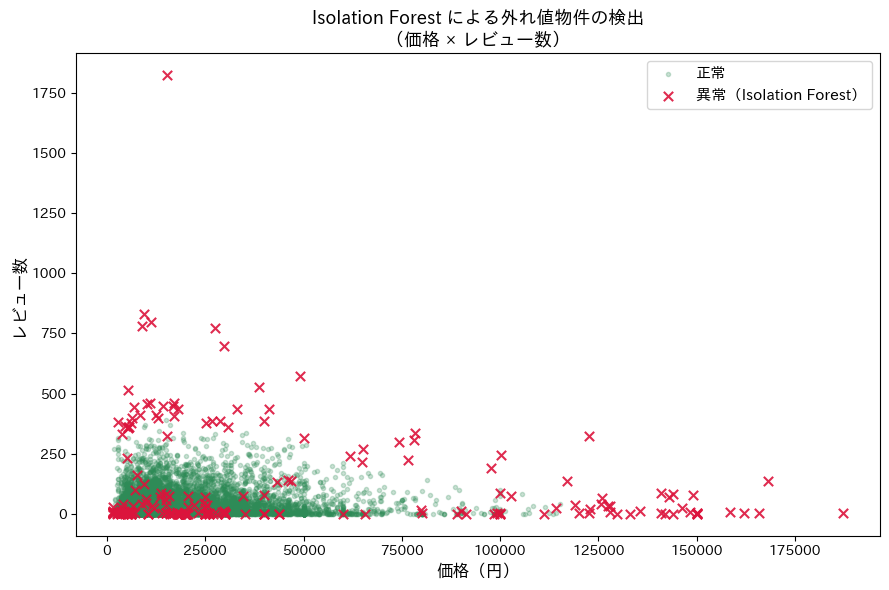

In [14]:
# ※ PCAはまだ学んでいないので、ここでは解釈しやすい2つの軸
# (価格 × レビュー数)で散布図を描きます(前回のクラスタリング回と同じ方針)。
# 正常点は小さく半透明、異常点は色とマーカーで強調します。

normal = df_anom[df_anom["iso_pred"] == 1]
anom = df_anom[df_anom["iso_pred"] == -1]
fig, ax = plt.subplots(figsize=(9, 6))

# 正常点：小さく・半透明に（前回のノイズ点と同じ作法 s=9, alpha=0.25）
ax.scatter(normal["price"], normal["number_of_reviews"], s=9, alpha=0.25, color="seagreen", label="正常")
# 異常点：大きく・目立つ色で
ax.scatter(anom["price"], anom["number_of_reviews"], s=45, alpha=0.9, color="crimson", marker="x", linewidths=1.5, label="異常（Isolation Forest）")

ax.set_xlabel("価格（円）", fontsize=12)
ax.set_ylabel("レビュー数", fontsize=12)
ax.set_title("Isolation Forest による外れ値物件の検出\n（価格 × レビュー数）", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
# LOF（局所外れ値因子）は「自分の周りの混み具合」を近傍と比べる手法。
# Isolation Forest とどれくらい結果が一致するかを見てみます。
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
df_anom["lof_pred"] = lof.fit_predict(X_scaled)

# 2つの手法が「両方とも異常」と判定した物件の数
both = ((df_anom["iso_pred"] == -1) & (df_anom["lof_pred"] == -1)).sum()
only_iso = ((df_anom["iso_pred"] == -1) & (df_anom["lof_pred"] == 1)).sum()
only_lof = ((df_anom["iso_pred"] == 1) & (df_anom["lof_pred"] == -1)).sum()

print("■ Isolation Forest と LOF の比較：")
print(f"  両方が異常と判定 ： {both:,} 件")
print(f"  IFのみが異常     ： {only_iso:,} 件")
print(f"  LOFのみが異常    ： {only_lof:,} 件")
print("\n→ 手法によって『異常』の定義が違うため、結果は完全には一致しません。")
print("  どちらが正しいということではなく、目的に応じて使い分けます。")

■ Isolation Forest と LOF の比較：
  両方が異常と判定 ： 68 件
  IFのみが異常     ： 155 件
  LOFのみが異常    ： 155 件

→ 手法によって『異常』の定義が違うため、結果は完全には一致しません。
  どちらが正しいということではなく、目的に応じて使い分けます。
